# Preparing Dataset for Fine-Tuning

In [3]:
# Imports:

import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [4]:
# Log in to Hugging Face:
load_dotenv(override= True)
hf_token = os.getenv("HF_TOKEN")
login(token= hf_token, add_to_git_credential= True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
# Loading Full Version of Dataset from Hugging Face:
dataset_full = 'ed-donner/items_full'

train, val, test = Item.from_hub(dataset_name= dataset_full)
items = train + val + test
print(f'Loaded {len(train)} Training Items, {len(val)} Validation Items, {len(test)} Test Items.')

Loaded 800000 Training Items, 10000 Validation Items, 10000 Test Items.


## Base Model and Tokenizer:

In [6]:
BASE_MODEL = 'meta-llama/Llama-3.2-3B'
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

## Token Count in Full Dataset:

In [8]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

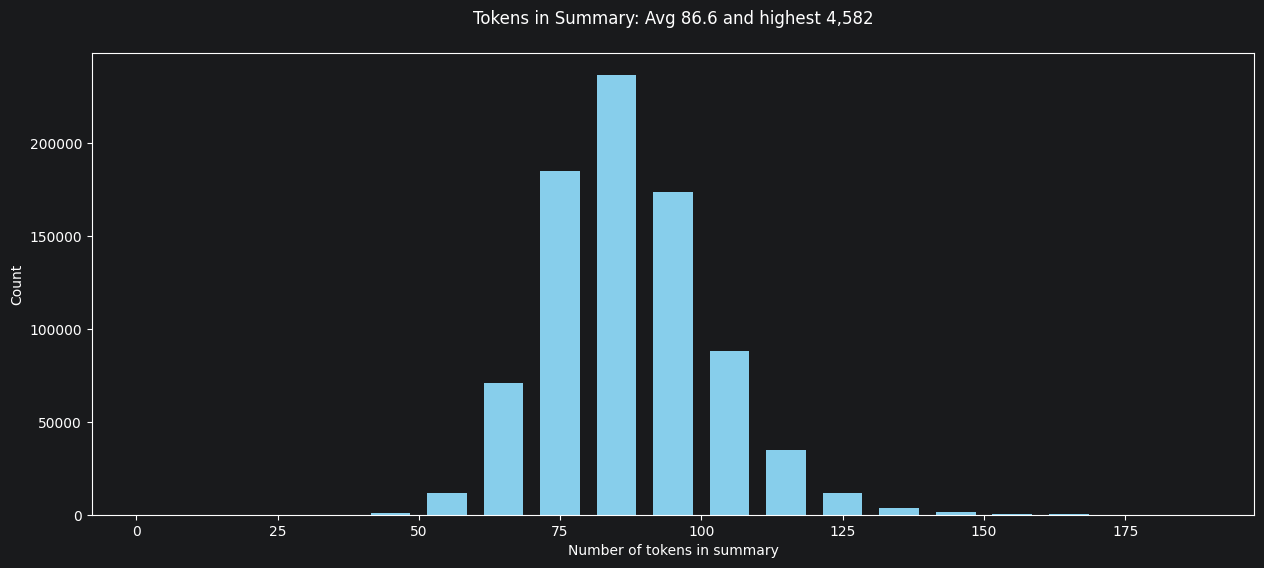

In [9]:
# Plotting Distribution for Number of Tokens:
plt.figure(figsize= (15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth= 0.7, color= "skyblue", bins= range(0, 200, 10))
plt.show()